# Telco Customer Data Churn Analysis (Supervised and Unsupervised Learning Models)

---

- **Author:** `Hunter Worssam`  
- **Date:** `<10-12-2025>`  

---

## README (Execution & Setup)

- **Python version:** `3.10.18`
- **Required packages:** `numpy`, `pandas`, `scikit-learn`, `matplotlib`, `scipy`
- **Install instructions:**
  ```bash
  # pip install numpy pandas scikit-learn matplotlib scipy
  ```
    ```
    ```
- **Datasets used:**
  - File names and sources:
  - https://www.kaggle.com/datasets/blastchar/telco-customer-churn
    ```
    ```
- **How to run this notebook:**
  
  1. Create a folder in your local directory titled "data", and place the dataset csv's from the links above inside.
  2. Run all cells in order (Kernel → Restart & Run All).
  3. Verify that all outputs match those in the **Sample Tests** section.
  4. Ensure figures and tables render correctly.

**Hint**: Place `WA_Fn-UseC_-Telco-Customer-Churn.csv` in `./data/`. The dataset can be downloaded from Kaggle using the links above.

---

## References

The LaTeX version uses **biblatex** with `\addbibresource{bibliographies.bib}` and renders references with `\printbibliography`. The following BibTeX keys are cited within PA1:

- `Hastie2009`, `Bishop2006`, `Pedregosa2011`, `Fawcett2006`
- `breiman_2001`, `cortes1995support`
- `macqueen1967some`, `rousseeuw1987silhouettes`, `calinski1974dendrite`, `Dempster1977`
- `Vaswani2017`, `wolf2020transformers`, `brockman2016openai`, `sutton2018reinforcement`
- `He2016`, `Krizhevsky2012`, `huggingface_transformers`, `Kaggle_Telco_Customer_Dataset`

> **Note:** When submitting this notebook, keep your narrative and citations inline here. 


## Setup

In [6]:
# Stdlib
import os, sys, json, time, math, random
from pathlib import Path

# Core
import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

# Plotting
import matplotlib.pyplot as plt

# sklearn: model selection & pipelines
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, StratifiedShuffleSplit,
    cross_val_score, GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

# sklearn: supervised models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# sklearn: metrics
from sklearn.metrics import (
    make_scorer, f1_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, average_precision_score, precision_recall_curve,
    silhouette_score, calinski_harabasz_score, davies_bouldin_score,
    adjusted_rand_score, normalized_mutual_info_score
)

# sklearn: clustering
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.neighbors import NearestNeighbors

# scipy: dendrograms
from scipy.cluster.hierarchy import linkage as scipy_linkage, dendrogram

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print('Python:', sys.version)
print('Seed set to:', SEED)


Python: 3.10.18 | packaged by conda-forge | (main, Jun  4 2025, 14:46:00) [Clang 18.1.8 ]
Seed set to: 42


## Part 1 — Investigation and Preprocessing of the Telco Customer Dataset

### Part 1a: Data Retrival 

For this project I will leverage the `Kaggle_Telco_Customer_Dataset` with the end goal of accurately predicting churn depending on features such as gender, tenure, total spend, payment method, product plan, etc. Below I am loading in the dataset, pulling out my target variable, establishing an 85%/15% train/test set (stratified to churn variable), and initializing a k-fold cross validation procedure with k=5.

In [8]:
# Reuse SEED variable defined earlier
# SEED = 42

# Load
data_path = Path("data") / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(data_path)

# Drop customerID column since it adds no value
df = df.drop(columns=["customerID"], errors="ignore")

# Identify target and features
target = "Churn"
y = df[target]
X = df.drop(columns=[target])

# Inspect target distribution to confirm need for stratification
print("Class counts:\n", y.value_counts(dropna=False))
print(f'')
print("Class ratio:\n", (y.value_counts(normalize=True) * 100).round(2).astype(str) + "%")

# Train/test split (85/15), stratified
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y,
    test_size=0.15,
    stratify=y,          # keep class proportions
    random_state=SEED
)

# Define 5-fold stratified CV for later hyperparameter tuning (on X_tr/y_tr only)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print(f'')
print(f"Shapes — X_tr: {X_tr.shape}, X_te: {X_te.shape}")

Class counts:
 Churn
No     5174
Yes    1869
Name: count, dtype: int64

Class ratio:
 Churn
No     73.46%
Yes    26.54%
Name: proportion, dtype: object

Shapes — X_tr: (5986, 19), X_te: (1057, 19)


I am using the IBM Telco Customer Churn dataset (7,043 rows; 21 variables) from Kaggle, which records telecom customers’ demographics, services, billing, and a binary churn label (Churn). Our target variable to predict will be the variable Churn (“Yes”/“No”), which tells us whether or not a customer remained on a service plan with us. I created a stratified 85/15 train/test split with SEED=42, and performed 5-fold stratified cross-validation within the 85% training pool for model selection. Using the 85% training split, I will leverage K-fold cross validation during the hyperparameter tuning stage. The same standardization and imputation methods will be built into that k-fold cross val procedure to ensure that each training split uses the same imputation and standardization pipeline. Stratification will be used because Churn is imbalanced (~26–27% “Yes”), and all preprocessing (imputation/standardization/encoding) will be fit on train folds only and applied unchanged to validation. The standardization/imputation performed on the test set will be the same used for the final model trained on the full 85% training set.

## Part 1b: Data quality & cleaning

Now we can proceed with splitting our features into numerical/categorical buckets and performing some statistical EDA in addition to checking for missingness or input errors. 

In [12]:
# Force the intended numeric columns
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

# Coerce to numeric (safe for EDA; imputation happens later inside the pipeline)
for c in num_cols:
    if c == "TotalCharges":
        df[c] = pd.to_numeric(df[c], errors="coerce")
    else:
        # If something came in as object by accident, coerce
        if not pd.api.types.is_numeric_dtype(df[c]):
            df[c] = pd.to_numeric(df[c], errors="coerce")

# 3) Everything else (except target) is categorical 
all_feature_cols = [c for c in df.columns if c != target]
cat_cols = [c for c in all_feature_cols if c not in num_cols]

# Make categoricals explicit for EDA cleanliness
for c in cat_cols:
    df[c] = df[c].astype("category")

print("Numeric columns:", num_cols)
print("Categorical columns (count):", len(cat_cols))

# Missingness snapshot on the numeric columns
print(f'')
print(f'Missingness in the numeric columns:')
print(df[num_cols].isna().sum().rename("missing_count"))


Numeric columns: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns (count): 16

Missingness in the numeric columns:
tenure             0
MonthlyCharges     0
TotalCharges      11
Name: missing_count, dtype: int64


We only have three standard numerical features in tenure, Monthly Charges and Total Charges, and there is only slight missingness observed in the Total Charges column. Given that we have over 7000 rows in our dataset, this missingess will be very easy to deal with, likely through median/mean imputation. We'll cover that later once we define our final train/validation splits. 

Starting with just the numerical features, we can check the standard IQR quartiles, mean, median, skew, kurtosis among other useful statistics. I also include a quick outlier detection column that uses q1 - 1.5*IQR, and q3 + 1.5*IQR to quickly flag any outliers. 

In [15]:
# Numeric EDA
def numeric_eda(df, cols):
    stats = []
    for c in cols:
        s = df[c]
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
        outliers = ((s < lo) | (s > hi)).sum()
        stats.append({
            "feature": c,
            "count": int(s.count()),
            "missing": int(s.isna().sum()),
            "nunique": int(s.nunique(dropna=True)),
            "mean": s.mean(),
            "std": s.std(),
            "min": s.min(),
            "q1": q1,
            "median": s.median(),
            "q3": q3,
            "max": s.max(),
            "skew": s.skew(),
            "kurtosis": s.kurtosis(),
            "iqr": iqr,
            "lower_bound(q1-1.5*iqr)": lo,
            "upper_bound(q3+1.5*iqr)": hi,
            "outlier_count(IQR)": int(outliers),
            "zero_count": int((s == 0).sum())
        })
    return pd.DataFrame(stats).set_index("feature").round(3)

num_summary = numeric_eda(df, num_cols)
print("=== Numeric EDA Summary ===")
display(num_summary)

=== Numeric EDA Summary ===


,count,missing,nunique,mean,std,min,q1,median,q3,max,skew,kurtosis,iqr,lower_bound(q1-1.5*iqr),upper_bound(q3+1.5*iqr),outlier_count(IQR),zero_count
feature,,,,,,,,,,,,,,,,,
tenure,7043,0,73,32.371,24.559,0.00,9.00,29.000,55.000,72.00,0.240,-1.387,46.000,-60.000,124.000,0,11
MonthlyCharges,7043,0,1585,64.762,30.090,18.25,35.50,70.350,89.850,118.75,-0.221,-1.257,54.350,-46.025,171.375,0,0
TotalCharges,7032,11,6530,2283.300,2266.771,18.80,401.45,1397.475,3794.738,8684.80,0.962,-0.232,3393.288,-4688.481,8884.669,0,0


Conveniently we only have 11 missing values total across our three numerical features, so this shouldn't be too difficult to deal with later on in our train set. Tenure and Monthly Charges have minimal skew, with median and mean of each being roughly similar. Tenure has a slight skew towards a higher number of months, and Monthly Charges has a slight skew towards lower charges. Total charges on the other hand is clearly influenced by some large values as the mean is significantly larger than the median. We will likely have to use the median to impute those missing values rather than the mean given the large right tail. Ideally I would leverage a random forest for imputation, but with only 11 missing values it feels a bit overkill for this instance. Our IQR-based method of outler detection didn't flag anything, but for peace of mind let's generate a visual to confirm this.

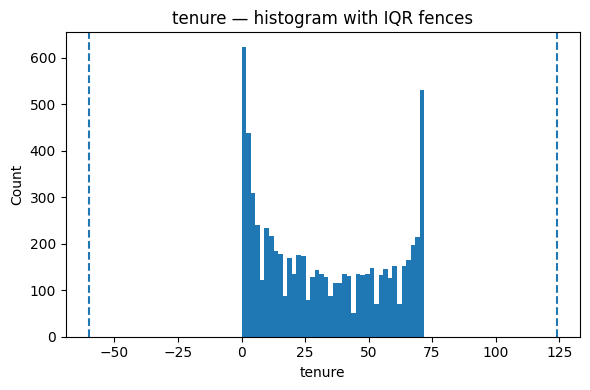

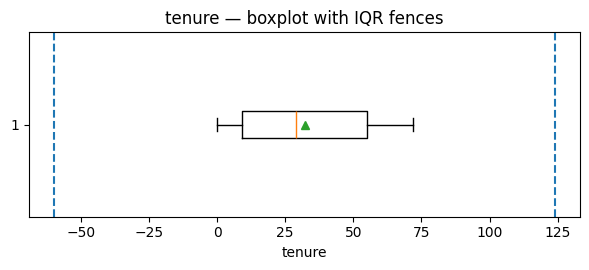

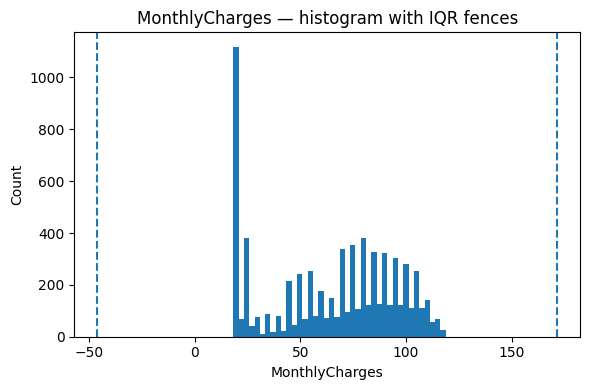

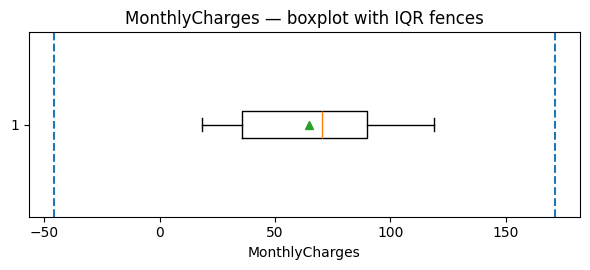

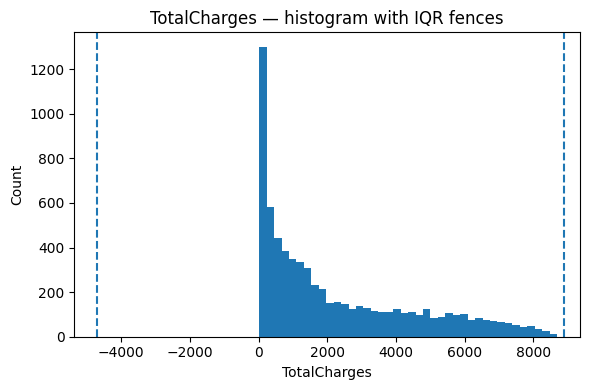

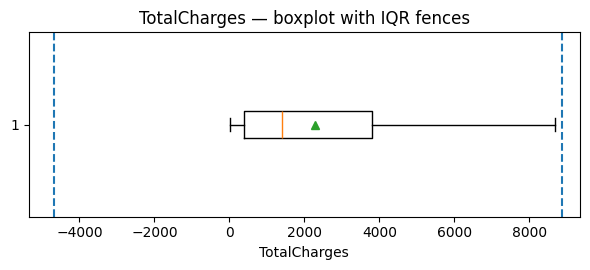

In [17]:
def iqr_stats(s: pd.Series):
    s = s.dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    out_n = ((s < lo) | (s > hi)).sum()
    return {"q1": q1, "q3": q3, "iqr": iqr, "lower": lo, "upper": hi, "outliers": int(out_n), "n": int(s.size)}

# Plots: histogram + boxplot per feature, with IQR fences
for c in num_cols:
    s = df[c].dropna()
    st = iqr_stats(s)
    lo, hi = st["lower"], st["upper"]

    # Histogram
    plt.figure(figsize=(6,4))
    plt.hist(s, bins=40)
    plt.axvline(lo, linestyle="--")
    plt.axvline(hi, linestyle="--")
    plt.title(f"{c} — histogram with IQR fences")
    plt.xlabel(c); plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    # Boxplot
    plt.figure(figsize=(6,2.8))
    plt.boxplot(s, vert=False, showmeans=True)
    plt.axvline(lo, linestyle="--")
    plt.axvline(hi, linestyle="--")
    plt.title(f"{c} — boxplot with IQR fences")
    plt.xlabel(c)
    plt.tight_layout()
    plt.show()


 We certainly don't see any glaring outliers in the tenure or monthly charges graphs. For tenure we have a pretty spread distribution between 15 and 60 months, with large local peaks around 0-10 months and 70-72 months. This makes sense as many customers are either signing up to try out the service for a year, or have likely been long time customers. I also don't see anything too glaring in the charges plots. In the total charges plot we slowly taper off as we get north of $6000 in total charges, but there are no obvious outliers present. Now let's proceed with our categorical variable EDA.

In [19]:
# Categorical EDA 
# High-level table first
cat_overview = pd.DataFrame({
    "missing": [df[c].isna().sum() for c in cat_cols],
    "nunique": [df[c].nunique(dropna=True) for c in cat_cols],
    "top": [df[c].mode(dropna=True).iat[0] if df[c].dropna().size else np.nan for c in cat_cols],
    "top_freq": [df[c].value_counts(dropna=True).iloc[0] if df[c].dropna().size else 0 for c in cat_cols]
}, index=cat_cols).sort_index()

print("\n=== Categorical Overview (missing, nunique, top level) ===")
display(cat_overview)

# Per-column value counts (including NaN) — top 20 each
print("\n=== Categorical Value Counts (top 20 per column; includes NaN) ===")
for c in cat_cols:
    print(f"\n--- {c} ---")
    vc = df[c].value_counts(dropna=False).head(20)
    print(vc)


=== Categorical Overview (missing, nunique, top level) ===


,missing,nunique,top,top_freq
Contract,0,3,Month-to-month,3875
Dependents,0,2,No,4933
DeviceProtection,0,3,No,3095
InternetService,0,3,Fiber optic,3096
MultipleLines,0,3,No,3390
OnlineBackup,0,3,No,3088
OnlineSecurity,0,3,No,3498
PaperlessBilling,0,2,Yes,4171
Partner,0,2,No,3641
PaymentMethod,0,4,Electronic check,2365



=== Categorical Value Counts (top 20 per column; includes NaN) ===

--- gender ---
gender
Male      3555
Female    3488
Name: count, dtype: int64

--- SeniorCitizen ---
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

--- Partner ---
Partner
No     3641
Yes    3402
Name: count, dtype: int64

--- Dependents ---
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

--- PhoneService ---
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

--- MultipleLines ---
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

--- InternetService ---
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

--- OnlineSecurity ---
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

--- OnlineBackup ---
OnlineBackup
No                     3088
Yes                    2429
No internet service    1

It's great to see that all of our data for each categorical variable falls within one of our expected buckets. Additionally, many of our cat variables are binary in nature, so our downstream one-hot-encoding step shouldn't result in a large number of extra dimensions. Based on the available options within each bucket, one hot encoding should increase our categorical feature count from 16 to 27. Some feature ranking that will be performed may be able to reduce this further. In that regard, it could be interesting to inpect churn rate as a function of these categorical variables. Let's proceed with this idea.

In [21]:
# Churn rate by category level
for c in cat_cols:
    print(f"\n>> Churn rate by {c}")
    tab = (
        df.groupby(c, dropna=False, observed=True)[target]
          .value_counts(normalize=True, dropna=False)
          .rename("prop")
          .reset_index()
    )
    tab_yes = (tab.loc[tab[target] == "Yes", [c, "prop"]]
                  .sort_values("prop", ascending=False))
    print(tab_yes.head(10).to_string(index=False))


>> Churn rate by gender
gender     prop
Female 0.269209
  Male 0.261603

>> Churn rate by SeniorCitizen
SeniorCitizen     prop
            1 0.416813
            0 0.236062

>> Churn rate by Partner
Partner     prop
     No 0.329580
    Yes 0.196649

>> Churn rate by Dependents
Dependents     prop
        No 0.312791
       Yes 0.154502

>> Churn rate by PhoneService
PhoneService     prop
         Yes 0.267096
          No 0.249267

>> Churn rate by MultipleLines
   MultipleLines     prop
             Yes 0.286099
              No 0.250442
No phone service 0.249267

>> Churn rate by InternetService
InternetService     prop
    Fiber optic 0.418928
            DSL 0.189591
             No 0.074050

>> Churn rate by OnlineSecurity
     OnlineSecurity     prop
                 No 0.417667
                Yes 0.146112
No internet service 0.074050

>> Churn rate by OnlineBackup
       OnlineBackup     prop
                 No 0.399288
                Yes 0.215315
No internet service 0.0740

WHile not entirely indicative of feature importance, these results are certainly interesting. While interpreting these results it's important to keep in mind that these numbers do not contextualize the frequency of each category in the dataset, so high churn proportion could simply be due to that feature outcome dominating the dataset. We can note that the global churn rate in the dataset was about 26.5%. It appears some buckets with high churn include senior citizens (41.6%), customers with fiber optic internet (41.9%), those with no online security (41.7%), those with no online backup (39.9%), those with no device protection (39.1%), those with no tech support (41.6%), those with month-to-month contracts (42.7%), and those who pay via electronic check (45.3%). Of these, the senior citizen finding is the most interesting since being a senior citizen is rather uncommon in the dataset relative to these other buckets. We'll investigate this further during feature ranking.   

As a final check before moving on to feature ranking and model building, I will check for any duplicates in the data.

In [24]:
# Check ID uniqueness if present
if "customerID" in df.columns:
    n_id = df["customerID"].nunique(dropna=False)
    print(f"customerID unique values: {n_id} / {len(df)} "
          f"({'OK unique' if n_id==len(df) else 'DUPLICATES FOUND'})")

# Exact row duplicates (all columns identical)
dup_all_mask = df.duplicated(keep=False)
n_dup_all = int(dup_all_mask.sum())
print(f"\nExact duplicate rows: {n_dup_all}")
if n_dup_all:
    display(df.loc[dup_all_mask].head(25))

# Feature-duplicates (same features regardless of label)
feature_cols = [c for c in df.columns if c != target]
dup_feat_mask = df.duplicated(subset=feature_cols, keep=False)
n_dup_feat = int(dup_feat_mask.sum())
print(f"\nFeature-duplicate rows (ignoring {target}): {n_dup_feat}")
if n_dup_feat:
    display(df.loc[dup_feat_mask, feature_cols + [target]].head(25))


Exact duplicate rows: 42


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
22,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.15,20.15,Yes
100,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.20,20.20,No
542,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,No
646,Male,0,No,No,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,45.70,45.70,Yes
662,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.05,20.05,No
690,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.45,20.45,No
964,Male,0,No,No,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,45.70,45.70,Yes
976,Male,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.90,69.90,Yes
1243,Male,0,No,No,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Electronic check,45.30,45.30,Yes
1338,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.15,20.15,Yes



Feature-duplicate rows (ignoring Churn): 73


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
22,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.15,20.15,Yes
100,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.20,20.20,No
128,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.75,19.75,No
295,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.25,20.25,No
542,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,No
646,Male,0,No,No,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,45.70,45.70,Yes
662,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.05,20.05,No
684,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,No,Mailed check,71.10,71.10,No
690,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.45,20.45,No
710,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,Yes


In the first block of code, I scan the customerID column for duplicates, which does not return any matches. In the second block of code, I scan the full dataset for rows where all features + churn match another in the dataset, and in the third block i do the same while ignoring churn outcome. It's clear to me that a lot of these duplicates are simply new customers who may have signed up purely for phone service and are on a very basic list of services. Given the simplification that takes place across the features when only phone service or single-internet service is purchased, it's totally reasonable that ~73 rows in the dataset may match up this closely. I will not move forward with removing any of these "duplicates" as I think it's reasonable that they are real customers.

## Part 1c: Feature Preprocessing

To begin with the feature preprocessing section, I'm going to proceed under the assumption that the stratified 85% training split I took early will be folded into a k-fold cross-validation procedure where each fold (train/val pair) will leverage the same imputation/standardization pipeline to avoid leakage. I'll also note that we've already defined our cross validation procedure as 'cv' back in the first block of code.

In [28]:
# Columns
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_cols = [c for c in X_tr.columns if c not in num_cols]

def coerce_numeric_frame(X):
    X = X.copy()
    # strip whitespace-only → NaN, then to numeric
    for col in X.columns:
        X[col] = pd.to_numeric(
            pd.Series(X[col], index=X.index).astype(str).str.strip().replace({"": np.nan}),
            errors="coerce"
        )
    return X

# Preprocessing lives inside the pipeline to avoid leakage
num_pre = Pipeline([
    ("coerce", FunctionTransformer(coerce_numeric_frame, feature_names_out="one-to-one")),
    ("imp", SimpleImputer(strategy="median")),
    ("sc", StandardScaler())
])

cat_pre = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False))
])

pre = ColumnTransformer([
    ("num", num_pre, num_cols),
    ("cat", cat_pre, cat_cols),
])

As previously mentioned, the pipeline above will be run only once our cross validation algorithm has generated a training split from our x_tr dataset, and the fitted preprocessing pipeline will then be applied to that folds' accompanied validation data. Once the optimal hyperparameter stack has been identified through k-fold CV, this preprocessing pipeline will again be run on the full training set (85% of total data), and then that fitted preprocessing pipeline will be applied to the test set for a final evaluation. This methodology fully avoids leakage. During it's first run instance I will print out resulting distributions that arose from our imputation of the 11 missing 'Total Charges' values, as well as our OneHoteEncodings. Given the simplicity and scope of these operations, there is no reason to believe we'll stray far from the baseline distributions. 

Before we proceed to our supervised learning modelling, let's perform some feature ranking & selection to determine if we can reduce the complexity of our dataset at minimal incurred loss. For logistic regression, SVM and a shallow MLP, we may be able to handle dimensionality reduction within the model training process itself, but we have to be careful to make the input to all three models as similar as possible to enable a fair comparison.

Top 10 component variances: [0.3144 0.2024 0.075  0.0427 0.0345 0.0297 0.0288 0.0272 0.026  0.0245]
Components for 90% variance: 15
Components for 95% variance: 18


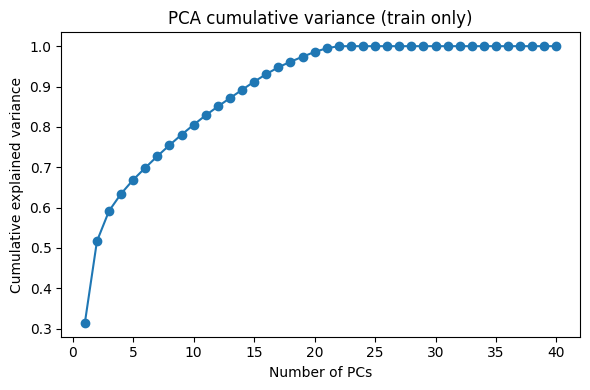

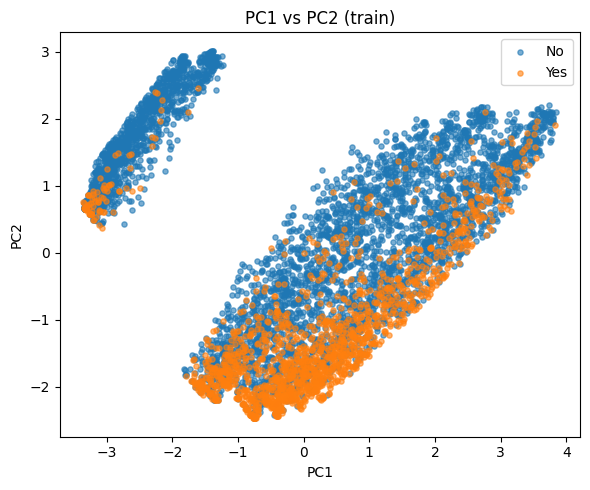

In [31]:
# Fit preprocessor on train only, then PCA on the processed train features.
Z_tr = pre.fit_transform(X_tr, y_tr)  # fit pre on train
pca = PCA(n_components=None, random_state=SEED)
pca.fit(Z_tr)

# Explained variance
evr = pca.explained_variance_ratio_
cum = np.cumsum(evr)

print("Top 10 component variances:", np.round(evr[:10], 4))
print("Components for 90% variance:", int(np.searchsorted(cum, 0.90) + 1))
print("Components for 95% variance:", int(np.searchsorted(cum, 0.95) + 1))

# Plot cumulative variance
plt.figure(figsize=(6,4))
plt.plot(range(1, len(cum)+1), cum, marker='o')
plt.xlabel("Number of PCs"); plt.ylabel("Cumulative explained variance")
plt.title("PCA cumulative variance (train only)")
plt.tight_layout(); plt.show()

# 2D visualization of PC1 vs PC2 colored by churn 
Z2 = pca.transform(Z_tr)[:, :2]
y_tr_bin = (y_tr.values == "Yes").astype(int)
plt.figure(figsize=(6,5))
plt.scatter(Z2[y_tr_bin==0,0], Z2[y_tr_bin==0,1], s=14, alpha=0.6, label="No")
plt.scatter(Z2[y_tr_bin==1,0], Z2[y_tr_bin==1,1], s=14, alpha=0.6, label="Yes")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("PC1 vs PC2 (train)")
plt.legend(); plt.tight_layout(); plt.show()

The PCA results show we can capture ~95% of the feature variance with ~18 components (well under half of the 40 post-OHE features). While PCA doesn’t target churn directly, the lower-dimensional, orthogonal space typically stabilizes optimization and speeds up distance-based methods (KMeans/Hierarchical/DBSCAN) and kernel models like RBF-SVM and MLP. For interpretability, I’ll keep the original feature space for Logistic Regression and use L1/Elastic-Net inside the pipeline to perform embedded selection and yield coefficient importances in the original feature space. For SVM, MLP, and the clustering methods, I’ll insert PCA(n≈18) after preprocessing so those models operate on a compact dataset, while I still report feature importance from the LR model in the original space.

In [33]:
# Fit the preprocessor on TRAIN ONLY (leakage-safe)
pre.fit(X_tr, y_tr)

# 2) Get post-transform feature names
num_names = num_cols  
ohe = pre.named_transformers_["cat"].named_steps["ohe"]
cat_names = ohe.get_feature_names_out(cat_cols)
feature_names = list(num_names) + list(cat_names)

print(f"Original features: {len(num_cols) + len(cat_cols)}")
print(f"Post-transform features: {len(feature_names)}")
print(f"")
print("Transformed feature names:", feature_names[:])

# Distribution of TotalCharges AFTER IMPUTATION (but BEFORE SCALING)
num_pipe = pre.named_transformers_["num"]
X_num_coerced  = num_pipe.named_steps["coerce"].transform(X_tr[num_cols])
X_num_imputed  = num_pipe.named_steps["imp"].transform(X_num_coerced)   # ndarray
imputer_stats  = num_pipe.named_steps["imp"].statistics_               

# Locate TotalCharges in the numeric array
tc_idx = num_cols.index("TotalCharges")
tc_imputed = pd.Series(X_num_imputed[:, tc_idx], index=X_tr.index, name="TotalCharges_imputed")

# Imputer median used for TotalCharges
tc_impute_value = imputer_stats[tc_idx]

# Summary stats (pre-scale)
tc_summary = pd.Series({
    "count":        tc_imputed.count(),
    "missing_after_impute": int(tc_imputed.isna().sum()),
    "mean":         tc_imputed.mean(),
    "std":          tc_imputed.std(),
    "min":          tc_imputed.min(),
    "q1":           tc_imputed.quantile(0.25),
    "median":       tc_imputed.median(),
    "q3":           tc_imputed.quantile(0.75),
    "max":          tc_imputed.max(),
    "skew":         tc_imputed.skew(),
    "kurtosis":     tc_imputed.kurtosis(),
    "imputer_median_used": tc_impute_value
}).round(4)

print("\n=== TotalCharges (after imputation, before scaling) ===")
print(tc_summary.to_string())

Original features: 19
Post-transform features: 40

Transformed feature names: ['tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'SeniorCitizen_1', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (auto

Following one hot encoding, we end up with 40 total features, three of which being numeric. Binary features are reduced to a single column, while features with n > 2 possible values are encoded into n unique columns. The concern with dropping one of the n feature value columns post-encoding is that unseen data are bucketed into that missing column by design, sort of like an intercept term in linear regression, even if the missing/unique value didn't belong in that bucket. My models should be robust enough to handle the few extra columns generated as a result of this encoding decision. Recall that we had 11 missing values in the TotalCharges column. The pre-imputation mean and standard deviation for TotalCharges on the full dataset was 2283, 2266 respectively. On the 85% training set, post-imputation, we now have a mean and standard deviation of 2285 and 2273 respectively. It's extremely likely the differences in training split are more impactful than our 11 imputations, so I am confident the process is low risk.

To summarize my preprocessing pipeline, I preprocess the dataset with a leakage-safe sklearn pipeline where TotalCharges is median-imputed and it along with the remaining two numerical features (tenure and MonthlyCharges) are standardized. All remaining features are One-Hot Encoded. No date-time fields exist in this dataset, so no special parsing is required. All transformers are fit only on the training folds during 5-fold stratified CV and then applied unchanged to validation/test (held-out 15%), ensuring no leakage. I also provide an example of the imputation on the full training set by showing pre/post distributions of the three numeric variables. For feature reduction, I will use two approaches inside the same pipeline depending on the model: (1) Logistic Regression with L1 regularization in the original feature space to yield interpretable coefficients; and (2) PCA after preprocessing (but before the estimator) for SVM/MLP, with the number of components tuned to between 15 and 20 based on total explained variance. PCA will improve optimization speed and stability without exposing validation/test data, and it will also be leveraged in part three for my three distance-based clustering approaches. Avoiding PCA for the logistic regression approach will give us the opportunity to observe feature importance in their original scales. All steps use SEED=42 for reproducibility.

## Part 2 — Supervised Learning Modelling for Churn Rate Prediction on the Telco Dataset

### Part 2a: Model Development

My plan below is to compare three complementary classifier families to balance linearity, nonlinearity, robustness, and interpretability. Logistic regression provides a linear decision boundary that is fast, stable, and highly interpretable. With L1 or Elastic-Net regularization, it handles multicollinearity and performs automatic feature selection, letting me rank native-space features driving churn. SVM with an RBF, linear or polynomial (TBD, will be a part of hyperparameter tuning) kernel captures nonlinear relationships via margin maximization; it’s typically robust in high-dimensional settings, and pairing it with PCA (18 PCs from my analysis) improves speed while preserving most of the signal. A shallow MLP (ReLU, logistic, identity or tanh activation function) also models nonlinear interactions and complex feature crosses. With standardization and early stopping it’s reasonably robust but less interpretable than Logistic Rregression. All three are wrapped in leakage-safe preprocessing pipelines that reuse the same preprocessing; PCA is applied only to SVM/MLP, while LR remains in the original feature space for interpretability, giving a clear linear baseline alongside two stronger nonlinear models.

In [40]:
# Model development: define pipelines & quick baseline CV

# PCA size based on your earlier PCA curve (~95% at ~18 comps)
N_PCS = 18

# Pipelines (pre is fit inside CV folds, leakage-safe)
# For Logistic regression, we'll start with L1 regularization but this will be tuned in part 2b
pipe_lr = Pipeline([
    ("pre", pre),
    ("clf", LogisticRegression(
        penalty="l1", solver="saga", max_iter=4000,
        random_state=SEED
    ))
])

# For svm, the kernel will be initiated as rbf, but this will be tuned in part 2b
pipe_svm = Pipeline([
    ("pre", pre),
    ("pca", PCA(n_components=N_PCS, random_state=SEED)),
    ("clf", SVC(kernel="rbf", probability=True, random_state=SEED))
])

pipe_mlp = Pipeline([
    ("pre", pre),
    ("pca", PCA(n_components=N_PCS, random_state=SEED)),
    ("clf", MLPClassifier(hidden_layer_sizes=(64,),
                          activation="relu",
                          alpha=1e-4,
                          early_stopping=True,
                          max_iter=600,
                          random_state=SEED))
])

models = {
    "LogReg_L1_noPCA": pipe_lr,
    "SVM_RBF_PCA": pipe_svm,
    "MLP_PCA": pipe_mlp,
}

# Baseline CV (untuned) to sanity-check everything
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
def cv_report(pipe, X, y, scoring="roc_auc"):
    scores = cross_val_score(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    return np.mean(scores), np.std(scores)

print("=== 5-fold CV baseline (untuned), scoring=ROC AUC ===")
for name, pipe in models.items():
    m, s = cv_report(pipe, X_tr, y_tr, scoring="roc_auc")
    print(f"{name:16s}  AUC: {m:.4f} ± {s:.4f}")

=== 5-fold CV baseline (untuned), scoring=ROC AUC ===
LogReg_L1_noPCA   AUC: 0.8433 ± 0.0034
SVM_RBF_PCA       AUC: 0.7925 ± 0.0061
MLP_PCA           AUC: 0.8377 ± 0.0081


Interestingly, in our baseline model runs the logistic regression model with L1 regularization has come out on top in terms of mean ROC-AUC score across 5-fold cross validation with a mean score of 0.8433 +/- 0.0034. Coming in just beihind was our MLP classifier using a RELU activation function with a mean ROC-AUC of 0.8377 +/- 0.0081. Lastly was our SVM model with an rbf kernel, coming in with an ROC-AUC mean of 0.7925 +/- 0.0061. Any standard deviation here is a function of the varied training sets derived from our k-fold cross validation procedure. Just incase PCA is somehow harming our SVM/MLP performance, let's rerun the baseline models without any PCA to see if we can get an improvement.

In [42]:
# Pipelines (no PCA)
pipe_svm_no_pca = Pipeline([
    ("pre", pre),
    ("clf", SVC(kernel="rbf", probability=True, random_state=SEED))
])

pipe_mlp_no_pca = Pipeline([
    ("pre", pre),
    ("clf", MLPClassifier(hidden_layer_sizes=(64,),
                          activation="relu",
                          alpha=1e-4,
                          early_stopping=True,
                          max_iter=600,
                          random_state=SEED))
])


models_no_pca = {
    "SVM_RBF_noPCA": pipe_svm_no_pca,
    "MLP_noPCA":     pipe_mlp_no_pca,
}

print("=== 5-fold CV baseline (untuned), scoring=ROC AUC — NO PCA ===")
for name, pipe in models_no_pca.items():
    m, s = cv_report(pipe, X_tr, y_tr, scoring="roc_auc")
    print(f"{name:16s}  AUC: {m:.4f} ± {s:.4f}")

=== 5-fold CV baseline (untuned), scoring=ROC AUC — NO PCA ===
SVM_RBF_noPCA     AUC: 0.7941 ± 0.0059
MLP_noPCA         AUC: 0.8417 ± 0.0042


The MLP mean ROC-AUC performance increased from 0.8377 to 0.8417, and the SVM model increased from 0.7925 to 0.7941 without PCA. These differences are extremely small, but the difference does imply that it may be worth testing the presence of PCA in our preprocessing pipeline as a hyperparameter. We will keep this in mind in the following section.

## Part 2b: Hyperparameter Optimization & Model Selection

For hyperparameters I’ll use sensible defaults plus small grids where it matters. For logistic regression, I’ll use the saga solver (supports L1/Elastic-Net on dense data) and tune penalty between L1 (sparse, interpretable) and Elastic-Net (more stable under correlated features), with a short grid over C and, if Elastic-Net wins, l1_ratio. For SVM, I’ll default to the RBF kernel since it's a strong nonlinear choice, and I'll pair it with my PCA step. I’ll tune C and gamma, and the number of pricipal components on a compact log-scale grid. For the MLP, I’ll fix ReLU activation instead of tanh/logistic since it trains fast and avoids vanishing gradients; and I'll use the adam solver since it yields robust results with standardized inputs. Then I'll tune hidden layer size and alpha for weight decay. All searches are run inside leakage-safe pipelines with 5-fold stratified CV (and SEED=42), letting CV decide the right regularization strength and PCA dimension while keeping the modeling choices focused and reproducible.

In [46]:
# Scoring dict: primary metrics only (ROC AUC, F1)
scoring = {
    "roc_auc": "roc_auc",
    "f1": make_scorer(f1_score, pos_label="Yes", zero_division=0),
}

# Logistic Regression (no PCA; interpretability in native space)
pipe_lr = Pipeline([
    ("pre", pre),
    ("clf", LogisticRegression(solver="saga", max_iter=4000, random_state=SEED))
])

lr_grid = [
    {"clf__penalty": ["l1"], "clf__C": [0.05, 0.1, 0.5, 1, 2, 5]},
    {"clf__penalty": ["elasticnet"], "clf__l1_ratio": [0.3, 0.5, 0.7],
     "clf__C": [0.05, 0.1, 0.5, 1, 2, 5]},
]

gs_lr = GridSearchCV(
    estimator=pipe_lr,
    param_grid=lr_grid,
    scoring=scoring,
    refit="roc_auc",       # refit on roc_auc as primary metric
    cv=cv,
    n_jobs=-1,
    return_train_score=False
)
gs_lr.fit(X_tr, y_tr)

# SVM with optional PCA
pipe_svm = Pipeline([
    ("pre", pre),
    ("pca", "passthrough"),
    ("clf", SVC(kernel="rbf", probability=True, random_state=SEED))
])
svm_grid = {
    "pca": ["passthrough",
            PCA(n_components=12, random_state=SEED),
            PCA(n_components=15, random_state=SEED),
            PCA(n_components=18, random_state=SEED),
            PCA(n_components=24, random_state=SEED),
            PCA(n_components=0.99, random_state=SEED)],
    "clf__C": [0.5, 1, 3],
    "clf__gamma": ["scale", 0.1, 0.01],
}
gs_svm = GridSearchCV(
    estimator=pipe_svm,
    param_grid=svm_grid,
    scoring=scoring,
    refit="roc_auc",
    cv=cv,
    n_jobs=-1,
    return_train_score=False
)
gs_svm.fit(X_tr, y_tr)

# MLP with optional PCA
pipe_mlp = Pipeline([
    ("pre", pre),
    ("pca", "passthrough"),
    ("clf", MLPClassifier(hidden_layer_sizes=(64,),
                          activation="relu",
                          alpha=1e-4,
                          early_stopping=True,
                          max_iter=800,
                          random_state=SEED))
])
mlp_grid = {
    "pca": ["passthrough",
            PCA(n_components=12, random_state=SEED),
            PCA(n_components=15, random_state=SEED),
            PCA(n_components=18, random_state=SEED),
            PCA(n_components=24, random_state=SEED),
            PCA(n_components=0.99, random_state=SEED)],
    "clf__hidden_layer_sizes": [(64,), (128,), (64, 32)],
    "clf__alpha": [1e-4, 1e-3],
}
gs_mlp = GridSearchCV(
    estimator=pipe_mlp,
    param_grid=mlp_grid,
    scoring=scoring,
    refit="roc_auc",
    cv=cv,
    n_jobs=-1,
    return_train_score=False
)
gs_mlp.fit(X_tr, y_tr)

# Summaries: mean ± std for each metric
def summarize(gs, label):
    df = pd.DataFrame(gs.cv_results_)
    df = df[[
        "mean_test_roc_auc","std_test_roc_auc",
        "mean_test_f1","std_test_f1","params"
    ]].copy()
    df.insert(0, "model", label)
    return df.sort_values("mean_test_roc_auc", ascending=False)

summary = pd.concat([
    summarize(gs_lr,  "LogReg"),
    summarize(gs_svm, "SVM_RBF"),
    summarize(gs_mlp, "MLP")
], ignore_index=True)

# Top configs per family
display(summary.groupby("model").head(3))

# Overall winner by ROC AUC (primary refit metric)
w_label, w_est, w_idx = max(
    [("LogReg", gs_lr, gs_lr.best_index_),
     ("SVM_RBF", gs_svm, gs_svm.best_index_),
     ("MLP", gs_mlp, gs_mlp.best_index_)],
    key=lambda t: t[1].cv_results_["mean_test_roc_auc"][t[2]]
)
print(f"Selected by ROC AUC: {w_label} | "
      f"ROC AUC={w_est.cv_results_['mean_test_roc_auc'][w_idx]:.4f}±{w_est.cv_results_['std_test_roc_auc'][w_idx]:.4f}, "
      f"F1={w_est.cv_results_['mean_test_f1'][w_idx]:.4f}±{w_est.cv_results_['std_test_f1'][w_idx]:.4f}")
print("Best params:", w_est.best_params_)

,model,mean_test_roc_auc,std_test_roc_auc,mean_test_f1,std_test_f1,params
0,LogReg,0.843302,0.002953,0.598814,0.008491,"{'clf__C': 5, 'clf__l1_ratio': 0.3, 'clf__penalty': 'elasticnet'}"
1,LogReg,0.843294,0.003416,0.596018,0.008556,"{'clf__C': 1, 'clf__penalty': 'l1'}"
2,LogReg,0.843284,0.003422,0.596036,0.008865,"{'clf__C': 1, 'clf__l1_ratio': 0.7, 'clf__penalty': 'elasticnet'}"
24,SVM_RBF,0.838791,0.004577,0.570722,0.003754,"{'clf__C': 0.5, 'clf__gamma': 0.01, 'pca': PCA(n_components=18, random_state=42)}"
25,SVM_RBF,0.838458,0.003200,0.570884,0.007885,"{'clf__C': 1, 'clf__gamma': 0.01, 'pca': PCA(n_components=18, random_state=42)}"
26,SVM_RBF,0.838241,0.004978,0.574310,0.006406,"{'clf__C': 0.5, 'clf__gamma': 0.01, 'pca': PCA(n_components=12, random_state=42)}"
78,MLP,0.841687,0.004128,0.588375,0.013403,"{'clf__alpha': 0.001, 'clf__hidden_layer_sizes': (64,), 'pca': 'passthrough'}"
79,MLP,0.841668,0.004177,0.593978,0.006734,"{'clf__alpha': 0.0001, 'clf__hidden_layer_sizes': (64,), 'pca': 'passthrough'}"
80,MLP,0.841519,0.004361,0.578962,0.016428,"{'clf__alpha': 0.001, 'clf__hidden_layer_sizes': (128,), 'pca': PCA(n_components=0.99, random_state=42)}"


Selected by ROC AUC: LogReg | ROC AUC=0.8433±0.0030, F1=0.5988±0.0085
Best params: {'clf__C': 5, 'clf__l1_ratio': 0.3, 'clf__penalty': 'elasticnet'}


To touch briefly on the two metrics I used for comparison above: ROC-AUC is threshold-free, meaning it measures how well the model ranks churners vs non-churners across all thresholds, so it’s relatively stable under class imbalance. F1 is threshold-dependent (defaults to 0.5 on the predicted probability) and summarizes the precision–recall trade-off at that single threshold. That’s why models with similar ROC-AUC can show different F1; they rank cases similarly overall, but their probability score scale differs, so 0.5 yields different precision/recall. Even though we stratified our folds in the preprocessing step, I will continue to use ROC-AUC as my primary decision-making metric. 

Our winning configuration overall was Logistic Regression with penalty='elasticnet', l1_ratio=0.3, C=5. Interpreting this, regularization was mostly L2 (70%) with a bit of L1 (30%) and a fairly weak overall regularization (C=5) constant was optimal. This fits OHE data well: L2 stabilizes correlated dummy variables, L1 prunes a few, and LR tends to give well-calibrated probabilities. It also achieved the best ROC-AUC (≈0.843) and the best F1 (≈0.599), with tiny fold std implying it was robust across splits. Interestingly, our l1_ratio and C parameters were at the edges of our grid, so we may be able to get better performance by expanding our grids accordingly. 

For SVM, top runs prefer small γ (0.01) and moderate C (0.5–1) with PCA enabled. 18 PCA components, comprising 95% of feature variance was generally optimal for the model. A smoother boundary (small γ) and moderate margin (C) generalize better in this dataset, and PCA likely helped conditioning and removed some OHE redundancy. ROC-AUC is close to LR (≈0.839) but F1 is lower (≈0.571) and the standard deviation was higher.

For MLP, best runs like small weight decay (alpha=1e-4) and moderate width (64), typically without PCA which was interesting. Based on the optimal results, it appears the MLP model wants to take in as many features as it can for optimal results, choosing either the most features via PCA, or no PCA at all. ROC-AUC is competitive (≈0.842) and F1 in the 0.589–0.594 range, slightly below LR. 

Before finalizing my model and running the test set, I want to expand my grid for LR to include lower l1_ratios and higher C values to ensure I am at the optimal setpoints.

In [49]:
scoring = {"roc_auc": "roc_auc",
           "f1": make_scorer(f1_score, pos_label="Yes", zero_division=0)}

lr_pipe = Pipeline([
    ("pre", pre),
    ("clf", LogisticRegression(solver="saga", max_iter=4000, random_state=SEED))
])

# Expand C around 5 and l1_ratio around 0.3
lr_grid_refined = {
    "clf__penalty": ["elasticnet"],
    "clf__l1_ratio": [0.10, 0.20, 0.30, 0.40, 0.50],
    "clf__C": [1.5, 2, 3, 5, 8, 12, 20],
}

gs_lr_refined = GridSearchCV(
    lr_pipe, lr_grid_refined,
    scoring=scoring, refit="roc_auc",
    cv=cv, n_jobs=-1, return_train_score=False
)
gs_lr_refined.fit(X_tr, y_tr)

res = pd.DataFrame(gs_lr_refined.cv_results_)[
    ["mean_test_roc_auc","std_test_roc_auc","mean_test_f1","std_test_f1","params"]
].sort_values("mean_test_roc_auc", ascending=False)
display(res.head(10))
print("Best:", gs_lr_refined.best_params_,
      "| ROC AUC=", round(gs_lr_refined.best_score_,4),
      "| F1=", round(res.iloc[0]["mean_test_f1"],4))

,mean_test_roc_auc,std_test_roc_auc,mean_test_f1,std_test_f1,params
15,0.843320,0.002936,0.599305,0.007892,"{'clf__C': 5, 'clf__l1_ratio': 0.1, 'clf__penalty': 'elasticnet'}"
16,0.843317,0.002951,0.599305,0.007892,"{'clf__C': 5, 'clf__l1_ratio': 0.2, 'clf__penalty': 'elasticnet'}"
17,0.843302,0.002953,0.598814,0.008491,"{'clf__C': 5, 'clf__l1_ratio': 0.3, 'clf__penalty': 'elasticnet'}"
10,0.843296,0.003013,0.598723,0.008382,"{'clf__C': 3, 'clf__l1_ratio': 0.1, 'clf__penalty': 'elasticnet'}"
18,0.843295,0.002947,0.599483,0.009090,"{'clf__C': 5, 'clf__l1_ratio': 0.4, 'clf__penalty': 'elasticnet'}"
19,0.843271,0.002944,0.599277,0.008707,"{'clf__C': 5, 'clf__l1_ratio': 0.5, 'clf__penalty': 'elasticnet'}"
11,0.843259,0.003016,0.598251,0.008458,"{'clf__C': 3, 'clf__l1_ratio': 0.2, 'clf__penalty': 'elasticnet'}"
5,0.843253,0.003124,0.598245,0.008523,"{'clf__C': 2, 'clf__l1_ratio': 0.1, 'clf__penalty': 'elasticnet'}"
12,0.843247,0.003048,0.598052,0.008481,"{'clf__C': 3, 'clf__l1_ratio': 0.3, 'clf__penalty': 'elasticnet'}"
20,0.843242,0.002794,0.599996,0.007366,"{'clf__C': 8, 'clf__l1_ratio': 0.1, 'clf__penalty': 'elasticnet'}"


Best: {'clf__C': 5, 'clf__l1_ratio': 0.1, 'clf__penalty': 'elasticnet'} | ROC AUC= 0.8433 | F1= 0.5993


The best configuration is C=5, l1_ratio=0.10 (Elastic Net), with ROC-AUC ≈ 0.8433 ± 0.0029 and F1 ≈ 0.5993 ± 0.0079. Several nearby settings—e.g., C ∈ {2,3,5} with l1_ratio ∈ {0.1–0.5}—are statistically indistinguishable (differences ≤ ~0.0003 AUC; F1 within ~0.001), indicating the model is insensitive to small changes in regularization around this region. For the final model I will carry forward Elastic Net, C=5, l1_ratio=0.10.

## Part 2c: Final Model Evaluation and Robustness

Now we can take our final logistic regression model and generate our confusion matrix, analyze the robustness of the performance via bootstrapping, and take a look at our native feature coefficients to derive an idea of which ones play a role in churn rate. 

In [53]:
# Final pipeline
final_lr = Pipeline([
    ("pre", pre),
    ("clf", LogisticRegression(
        solver="saga", penalty="elasticnet",
        l1_ratio=0.10, C=5.0,
        max_iter=4000, random_state=SEED
    ))
])

# Fit on full 85% training pool
final_lr.fit(X_tr, y_tr)

# Predict on held-out test 
proba_te = final_lr.predict_proba(X_te)[:, 1]          # P(churn="Yes")
pred_labels = np.where(proba_te >= 0.5, "Yes", "No")   

# Metrics (threshold-free + thresholded)
roc_auc = roc_auc_score(y_te, proba_te)
pr_auc  = average_precision_score(y_te, proba_te, pos_label="Yes")
f1      = f1_score(y_te, pred_labels, pos_label="Yes")

print(f"Test ROC-AUC: {roc_auc:.4f}")
print(f"Test PR-AUC (Average Precision, pos='Yes'): {pr_auc:.4f}")
print(f"Test F1 (threshold=0.5, pos='Yes'): {f1:.4f}\n")

print("Classification report (threshold=0.5):")
print(classification_report(y_te, pred_labels,
                            labels=["No","Yes"], target_names=["No","Yes"],
                            zero_division=0))

cm = confusion_matrix(y_te, pred_labels, labels=["No","Yes"])
cm_df = pd.DataFrame(cm, index=["Actual No","Actual Yes"], columns=["Pred No","Pred Yes"])
print("\nConfusion matrix:")
display(cm_df)

Test ROC-AUC: 0.8497
Test PR-AUC (Average Precision, pos='Yes'): 0.6343
Test F1 (threshold=0.5, pos='Yes'): 0.6077

Classification report (threshold=0.5):
              precision    recall  f1-score   support

          No       0.85      0.89      0.87       777
         Yes       0.66      0.56      0.61       280

    accuracy                           0.81      1057
   macro avg       0.75      0.73      0.74      1057
weighted avg       0.80      0.81      0.80      1057


Confusion matrix:


,Pred No,Pred Yes
Actual No,695,82
Actual Yes,122,158


From the confusion matrix (TN=695, FP=82, FN=122, TP=158), the model correctly identifies most non-churners but misses 122 churners at the 0.5 threshold. That yields precision ≈0.66 and recall ≈0.56 for the churn (“Yes”) class. When we flag churn we’re usually right, but we still overlook a fair number of churners. If the cost of missed churn is high, we should lower the decision threshold to trade some extra false positives for higher recall.

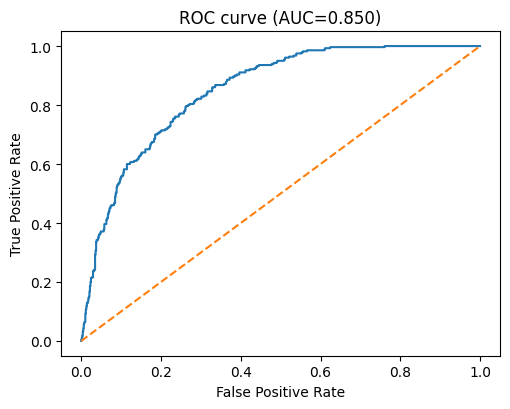

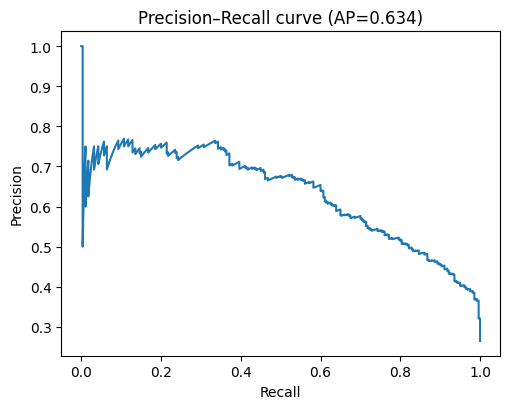

In [55]:
# Curves
fpr, tpr, _ = roc_curve(y_te, proba_te, pos_label="Yes")
prec, rec, _ = precision_recall_curve(y_te, proba_te, pos_label="Yes")

plt.figure(figsize=(5.2,4.2))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title(f"ROC curve (AUC={roc_auc:.3f})"); plt.tight_layout(); plt.show()

plt.figure(figsize=(5.2,4.2))
plt.plot(rec, prec)
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title(f"Precision–Recall curve (AP={pr_auc:.3f})"); plt.tight_layout(); plt.show()

ROC is smooth and PR curve is healthy, but it shows the usual precision drop as recall increases, so we can trade precision for more recall by moving the threshold left.

In [57]:
# Bootstrap CIs on test (stratified by label)
rng = np.random.default_rng(SEED)
def stratified_indices(y, n_boot=2000):
    y = np.asarray(y)
    idx_yes = np.where(y == "Yes")[0]
    idx_no  = np.where(y == "No")[0]
    for _ in range(n_boot):
        s_yes = rng.choice(idx_yes, size=len(idx_yes), replace=True)
        s_no  = rng.choice(idx_no,  size=len(idx_no),  replace=True)
        yield np.r_[s_yes, s_no]

def bootstrap_ci(metric_fn, y, proba, labels=None, n_boot=2000, alpha=0.05):
    vals = []
    for idx in stratified_indices(y, n_boot=n_boot):
        if labels is None:
            vals.append(metric_fn(y.iloc[idx], proba[idx]))
        else:
            # for thresholded metric like F1 we need hard labels at 0.5
            preds = np.where(proba[idx] >= 0.5, "Yes", "No")
            vals.append(metric_fn(y.iloc[idx], preds, pos_label="Yes"))
    lo, hi = np.quantile(vals, [alpha/2, 1-alpha/2])
    return float(lo), float(hi)

roc_ci = bootstrap_ci(roc_auc_score, y_te, proba_te, n_boot=2000)
f1_ci  = bootstrap_ci(f1_score, y_te, proba_te, labels=["No","Yes"], n_boot=2000)

print(f"\n95% CI (bootstrap, stratified, n=2000):")
print(f"ROC-AUC: {roc_auc:.3f} [{roc_ci[0]:.3f}, {roc_ci[1]:.3f}]")
print(f"F1@0.5 : {f1:.3f} [{f1_ci[0]:.3f}, {f1_ci[1]:.3f}]")


95% CI (bootstrap, stratified, n=2000):
ROC-AUC: 0.850 [0.827, 0.873]
F1@0.5 : 0.608 [0.559, 0.657]


The robustness around accuracy (ROC-AUC) is fairly strong, with roughly +/- 3% precision following our boostrap sampling procedure. Our model should generalize well to unseen data that follows a similar distribution as the one that generated this dataset.

In [59]:
# Pull post-OHE feature names from the fitted preprocessor
oh = final_lr.named_steps["pre"].named_transformers_["cat"].named_steps["ohe"]
cat_cols = [c for c in X_tr.columns if c not in ["tenure","MonthlyCharges","TotalCharges"]]
cat_names = oh.get_feature_names_out(cat_cols)
feat_names = np.r_[["tenure","MonthlyCharges","TotalCharges"], cat_names]

coefs = final_lr.named_steps["clf"].coef_.ravel()
coef_s = pd.Series(coefs, index=feat_names).sort_values()

print("\nTop 12 negative (retention-protective) features:")
display(coef_s.head(12).round(4).to_frame("coef"))

print("Top 12 positive (churn-prone) features:")
display(coef_s.tail(12).round(4).to_frame("coef"))


Top 12 negative (retention-protective) features:


,coef
MonthlyCharges,-1.3679
tenure,-1.3096
InternetService_DSL,-0.7446
Contract_Two year,-0.6502
OnlineSecurity_No internet service,-0.3646
TechSupport_No internet service,-0.3646
InternetService_No,-0.3646
StreamingTV_No internet service,-0.3646
OnlineBackup_No internet service,-0.3646
StreamingMovies_No internet service,-0.3646


Top 12 positive (churn-prone) features:


,coef
TechSupport_No,0.1726
SeniorCitizen_1,0.1749
DeviceProtection_Yes,0.1770
PhoneService_Yes,0.1859
PaymentMethod_Electronic check,0.3279
PaperlessBilling_Yes,0.3654
MultipleLines_Yes,0.3880
StreamingTV_Yes,0.5211
StreamingMovies_Yes,0.5305
TotalCharges,0.5928


As previously hypothesized, not having tech support and being a senior citizen turned out to be the two variables most predictive of churn. Perhaps as a company they could do a better job emphasizing tech support, or perhaps discounting it to reduce their churn rate. Tensure naturally correlates to low churn (obviously), as does having a multi-year contract and having tech support. 

## Part 3 — Unsupervised Learning Modelling of the Telco Customer Dataset

### Part 3a: Data Alignment and Documentation

Dataset: `IBM Telco Customer Churn` (Kaggle; ~7,043 rows, ~21 columns). It contains demographics, subscribed services, billing info, and an available label Churn (“Yes”/“No”). 

Preprocessing is carried over identical to Part 1.

Numeric Features (tenure, MonthlyCharges, TotalCharges): row-wise coercion to numeric (strip blanks → NaN), median impute for the 11 missing TotalCharge values, then StandardScaler.

Categorical Features (all others): no imputation needed, OneHotEncoder with handle_unknown="ignore" and drop="if_binary", meaning binary columns result in a single encoded column.

Everything is wrapped in the same sklearn ColumnTransformer pre and will be fit on the 85% training split only, then applied unchanged to any validation/test data to avoid leakage.

For distance-based clustering (KMeans, Hierarchical Clustering, DBSCAN) it will be even more important to leverage the previously established PCA step (~15–20 PCs, 18 for ~95% variance) after pre to denoise OHE redundancy and improve distance geometry.

Clustering is fully unsupervised: Churn is never used to fit the clusters. After clustering, we will use the label only for external validation, reporting Adjusted Rand Index (ARI) and Normalized Mutual Information (NMI) as sanity checks alongside internal indices such as Silhouette, Calinski–Harabasz and Davies–Bouldin. If I compare hyperparameter combinations, I'll select by internal criteria on the train split, and reserve ARI/NMI on the held-out test as a purely external check.

## Part 3b: Preprocessing and Dimensionality Reduction

Preprocessing & DR for clustering is even more instumental than it was for my supervised learning approaches. All transforms remain leakage-free by using the same pre (numeric: coerce -> median imputation-> standardize; categorical: OHE with drop='if_binary'), fitting it on the 85% train data, and applying unchanged to any evaluation split. Because KMeans, Hierarchical Clustering (with Euclidean/Ward), and DBSCAN are distance-based, scaling is essential, otherwise a high-variance feature (e.g., TotalCharges) or a wide categorical feature can dominate distances. I also include PCA after pre, typically 15–20 PCs (I previously saw ~95% variance at ~18 PCs). PCA helps by (i) denoising correlated one-hot columns, (ii) mitigating the curse of dimensionality so Euclidean neighborhoods are more meaningful, and (iii) improving numerical conditioning for KMeans inertia and linkage computations. For interpretability, I’ll keep cluster evaluations and inference in the original feature space, but use PCA both to fit clusters and for visualization.

### Part 3c: Clustering Models

To begin with my clustering models, I will start with building an optimal `Kmeans` model, using an inertia plot and silhouette score combination to select the best k for the Telco dataset. 

Elbow candidate k: 3 | Silhouette-max k: 3


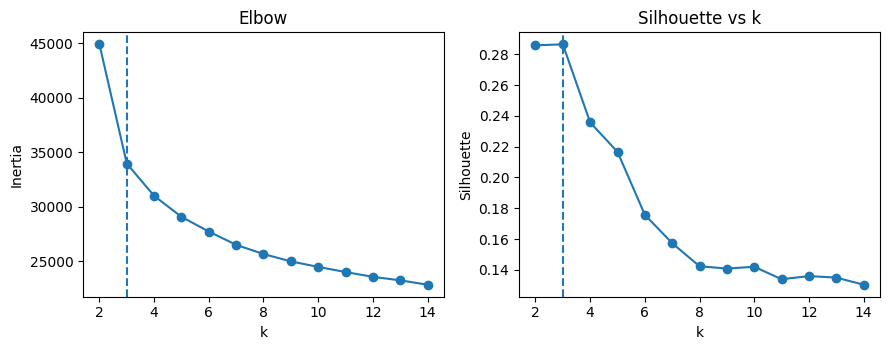

In [69]:
# K-Means: elbow + silhouette on TRAIN
# Preprocess + PCA: fit on train only then transform
pca18 = Pipeline([("pre", pre), ("pca", PCA(n_components=18, random_state=SEED))])
Z_tr = pca18.fit_transform(X_tr)   # fit on train
Z_te = pca18.transform(X_te)       # apply unchanged to test

# Scan k for elbow/silhouette 
ks = range(2, 15)
rows = []
for k in ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=SEED)
    km.fit(Z_tr)
    labels = km.labels_
    rows.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(Z_tr, labels, metric="euclidean"),
        "ch": calinski_harabasz_score(Z_tr, labels),
        "db": davies_bouldin_score(Z_tr, labels)
    })
km_df = pd.DataFrame(rows)

# Simple elbow heuristic: first k where relative inertia drop < 10%
rel_drop = km_df["inertia"].pct_change(-1).abs()  # drop from k to k+1
km_df["rel_drop_to_next"] = rel_drop
k_elbow = km_df.query("k < @ks.stop-1").loc[lambda d: d["rel_drop_to_next"] < 0.10]["k"].min()
# Fallbacks if heuristic finds nothing
if np.isnan(k_elbow): k_elbow = int(km_df.loc[km_df["silhouette"].idxmax(), "k"])
k_sil = int(km_df.loc[km_df["silhouette"].idxmax(), "k"])

print("Elbow candidate k:", k_elbow, "| Silhouette-max k:", k_sil)

# Plots: Elbow & Silhouette
fig, ax = plt.subplots(1,2, figsize=(9,3.6))
ax[0].plot(km_df["k"], km_df["inertia"], marker="o")
ax[0].set_xlabel("k"); ax[0].set_ylabel("Inertia"); ax[0].set_title("Elbow")
ax[0].axvline(k_elbow, ls="--")

ax[1].plot(km_df["k"], km_df["silhouette"], marker="o")
ax[1].set_xlabel("k"); ax[1].set_ylabel("Silhouette")
ax[1].set_title("Silhouette vs k"); ax[1].axvline(k_sil, ls="--")
plt.tight_layout(); plt.show()

# Fit final KMeans (pick silhouette-max by default
K_FINAL = k_sil
kmeans = KMeans(n_clusters=K_FINAL, n_init=20, random_state=SEED).fit(Z_tr)

Using the train-only preprocessing + 18 principal component space, K-Means shows a clear elbow at k=3 (big inertia drop from k=2→3, then diminishing returns) and the silhouette curve peaks at k=3 (~0.28–0.29) before steadily declining. This indicates the data support three moderately separated clusters, but the structure present is not very strong with a sil score of ~0.28, which can be expected for mixed customer data such as this. To test for stability in the next section, I will confirm stability across a wider range of PCA components, and I can also check a grid of n_init setpoints beyond == 20 as well as different seeds. 

For `Hierarchical CLustering` I will consider a variety of different linkage functions, including Ward, complete and average. I'll also scan a variety of k values for each linkage and pick the best one depending on max silhouette score. Finally, I'll provide dendrogram plots for each linkage to visualize the process.

,linkage,k,silhouette,ch,db
18,average,2,0.285769,2123.256745,1.194635
0,ward,2,0.285769,2123.256745,1.194635
11,complete,4,0.217143,1695.607127,2.112092


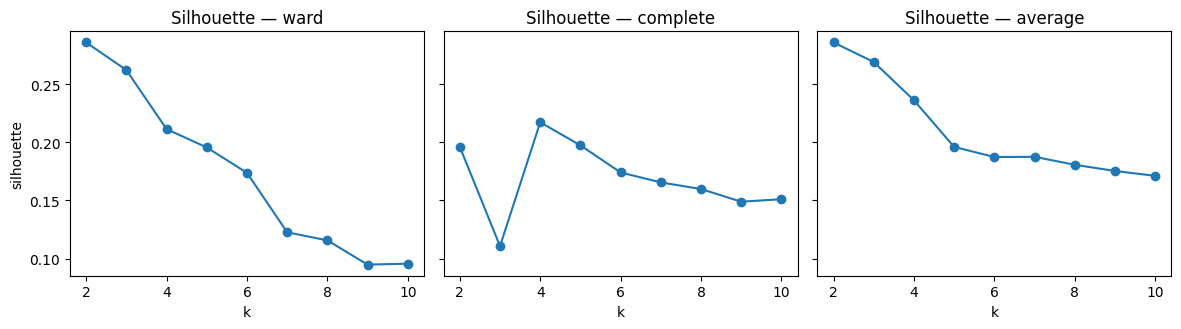

In [72]:
# Hierarchical clustering: linkage comparison + dendrogram
# Transform data (fitting train only)
pca18 = Pipeline([("pre", pre), ("pca", PCA(n_components=18, random_state=SEED))])
Z_tr = pca18.fit_transform(X_tr)   # fit transform on train
Z_te = pca18.transform(X_te)     

# Scan k for each linkage (Ward/complete/average)
linkages = ["ward", "complete", "average"]
ks = range(2, 11)

rows = []
for link in linkages:
    for k in ks:
        if link == "ward":
            cl = AgglomerativeClustering(n_clusters=k, linkage="ward")  # metric fixed to euclidean
        else:
            cl = AgglomerativeClustering(n_clusters=k, linkage=link, metric="euclidean")
        labels = cl.fit_predict(Z_tr)
        rows.append({
            "linkage": link,
            "k": k,
            "silhouette": silhouette_score(Z_tr, labels),
            "ch": calinski_harabasz_score(Z_tr, labels),
            "db": davies_bouldin_score(Z_tr, labels)
        })

h_df = pd.DataFrame(rows)
# Best k per linkage by silhouette
best_per_link = (h_df.loc[h_df.groupby("linkage")["silhouette"].idxmax()]
                 .sort_values("silhouette", ascending=False))
display(best_per_link)

# Plot silhouette vs k for each linkage
fig, ax = plt.subplots(1,3, figsize=(12,3.4), sharey=True)
for i, link in enumerate(linkages):
    d = h_df[h_df["linkage"]==link]
    ax[i].plot(d["k"], d["silhouette"], marker="o")
    ax[i].set_title(f"Silhouette — {link}")
    ax[i].set_xlabel("k")
    if i==0: ax[i].set_ylabel("silhouette")
plt.tight_layout(); plt.show()

Interestingly, both the ward and average linkage methods have the same silhouette score, but with slightly different silhouette trends as a function of k. CH and DB values are identical for both as well. If I had to select one purely off of this information, I would choose average since it has a more stable range of silhouette values as k increases, but let's observe the dendrograms to determine if one is more favorable. 

In [74]:
# Stratified, reproducible subsample (≈800 points) for readability
rng = np.random.default_rng(SEED)
idx_yes = np.where(np.array(y_tr) == "Yes")[0]
idx_no  = np.where(np.array(y_tr) == "No")[0]
n_vis = 800
n_yes = int(len(idx_yes) / len(X_tr) * n_vis)
n_no  = n_vis - n_yes
vis_idx = np.r_[rng.choice(idx_yes, n_yes, replace=False),
                rng.choice(idx_no,  n_no,  replace=False)]
Z_vis = Z_tr[vis_idx]

# Build both dendrograms 
methods = ["ward", "average"]  

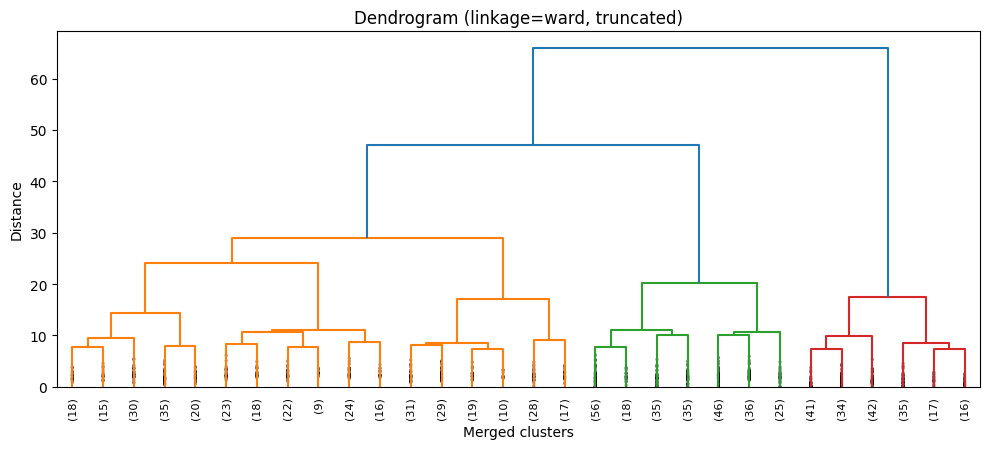

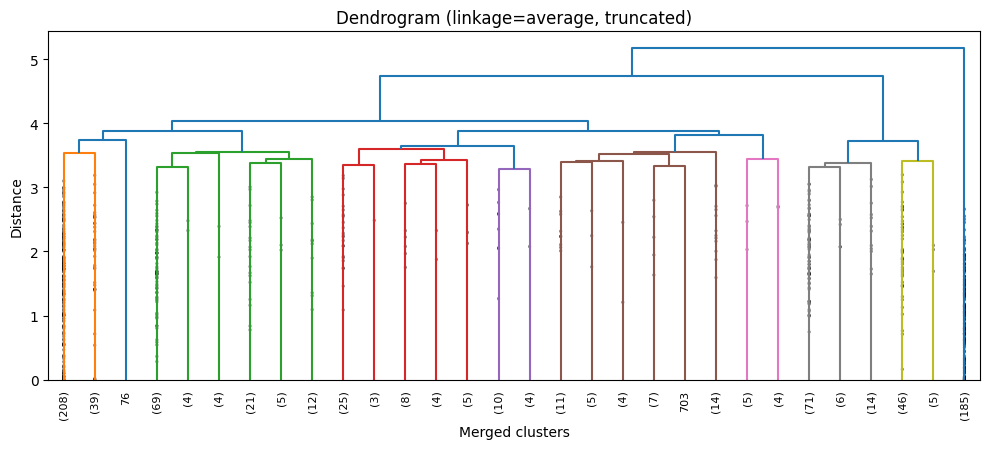

In [75]:
# Ward dendrogram
L_ward = scipy_linkage(Z_vis, method="ward", metric="euclidean")
plt.figure(figsize=(10, 4.6))
dendrogram(
    L_ward, truncate_mode="lastp", p=30, show_contracted=True,
    leaf_rotation=90, leaf_font_size=8, count_sort="descending"
)
plt.title("Dendrogram (linkage=ward, truncated)")
plt.xlabel("Merged clusters"); plt.ylabel("Distance")
plt.tight_layout(); plt.show()

# Average dendrogram 
L_average = scipy_linkage(Z_vis, method="average", metric="euclidean")
plt.figure(figsize=(10, 4.6))
dendrogram(
    L_average, truncate_mode="lastp", p=30, show_contracted=True,
    leaf_rotation=90, leaf_font_size=8, count_sort="descending"
)
plt.title("Dendrogram (linkage=average, truncated)")
plt.xlabel("Merged clusters"); plt.ylabel("Distance")
plt.tight_layout(); plt.show()

Both Ward and Average linkages peak at k=2 with essentially identical internal scores (silhouette ≈ 0.286, CH ≈ 2123, DB ≈ 1.195). Given the tie, I’d pick Ward since on PCA/Euclidean spaces it minimizes within-cluster variance, tends to produce more compact, interpretable clusters, and is the standard default `AgglomerativeCLustering`. The Ward dendrogram also shows a clear height gap at the final merge, supporting a 2-cluster cut.

`DBSCAN` (Density-Based Spatial Clustering of Applications with Noise) groups points that form dense regions and labels low-density points as noise. Unlike K-Means, it doesn’t require k, can find arbitrarily shaped clusters, and is robust to outliers; all of which is useful on churn data where small, tight segments of at-risk customers may exist alongside broad “non-churn” groups. It also naturally surfaces noisy customers whose behavior deviates from both groups. These would be prime candidates for targeted outreach. Because ε is measured in feature space, DBSCAN is scale-sensitive, so we must standardize features and work in a compact PCA(18) space before choosing (ε, minPts) via k-distance curves and a small grid search.

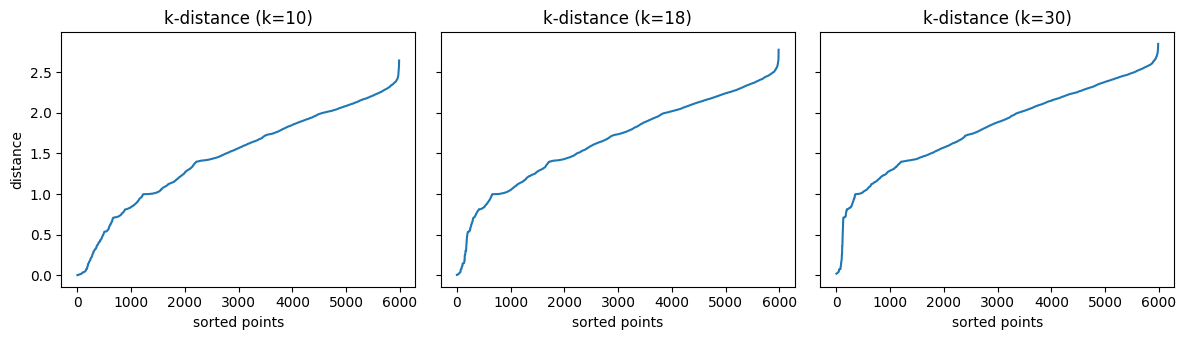

{10: 2.272247306215858, 18: 2.417912683729374, 30: 2.541557650345835}

In [78]:
# DBSCAN: fit on train and choose eps via k-distance + small grid
# Transform data 
pca18 = Pipeline([("pre", pre), ("pca", PCA(n_components=18, random_state=SEED))])
Z_tr = pca18.fit_transform(X_tr)
Z_te = pca18.transform(X_te)

# k-distance curves for a few minPts values
minpts_list = [10, 18, 30]
fig, ax = plt.subplots(1, len(minpts_list), figsize=(12, 3.5), sharey=True)
elbows = {}

for i, minpts in enumerate(minpts_list):
    nn = NearestNeighbors(n_neighbors=minpts, metric="euclidean").fit(Z_tr)
    dists, _ = nn.kneighbors(Z_tr)
    kth = np.sort(dists[:, -1])  
    ax[i].plot(np.arange(len(kth)), kth)
    ax[i].set_title(f"k-distance (k={minpts})")
    ax[i].set_xlabel("sorted points"); 
    if i == 0: ax[i].set_ylabel("distance")
    elbows[minpts] = np.quantile(kth, 0.95)

plt.tight_layout(); plt.show()

elbows  # a quick look at suggested eps per minPts

Each panel shows the sorted distance to the k-th nearest neighbor for every training point (with 𝑘 = minPts). The flat region on the left are points in dense areas (small k-NN distance). The knee/elbow marks the transition from dense regions to sparser points. The steep tail on the right are isolated points/outliers, so these plots help determine where to set your epsilon parameter.

For a chosen minPts, I set ε near the elbow of that curve, then scan ±10–20%. In the plots above, the 95th-percentile knee estimates are about:

minPts=10 -> ε ≈ 2.27

minPts=18 -> ε ≈ 2.42

minPts=30 -> ε ≈ 2.55

As minPts increases, the curve shifts up, meaning you need a larger ε to keep the same density portion.

ε too small means many points are labeled noise, with few clusters. ε too large means clusters merge into one big blob.

In [80]:
# Grid over (eps, minPts) around the elbow suggestions; evaluate on train
def eval_dbscan(Z, eps, minpts):
    labels = DBSCAN(eps=eps, min_samples=minpts, metric="euclidean", n_jobs=-1).fit_predict(Z)
    # count clusters (exclude noise label = -1)
    n_clu = len(set(labels)) - (1 if -1 in labels else 0)
    frac_noise = (labels == -1).mean()
    # internal indices only if we have at least 2 clusters
    if n_clu >= 2:
        mask = labels != -1
        try:
            sil = silhouette_score(Z[mask], labels[mask])
            ch  = calinski_harabasz_score(Z[mask], labels[mask])
            db  = davies_bouldin_score(Z[mask], labels[mask])
        except Exception:
            sil, ch, db = np.nan, np.nan, np.nan
    else:
        sil, ch, db = np.nan, np.nan, np.nan
    return {"n_clusters": n_clu, "noise_frac": frac_noise, "silhouette": sil, "ch": ch, "db": db}

rows = []
for minpts in minpts_list:
    base = elbows[minpts]
    # probe ±20% around the elbow plus the elbow itself
    cand_eps = [base*0.8, base*0.9, base, base*1.1, base*1.2]
    for eps in cand_eps:
        m = eval_dbscan(Z_tr, eps, minpts)
        m.update({"min_samples": minpts, "eps": eps})
        rows.append(m)

db_df = pd.DataFrame(rows)
# Defining a "good" regime:
# - at least 2 clusters, not all noise
# - moderate noise (e.g., <= 0.4)
# - maximize silhouette 
good = db_df.query("n_clusters >= 2 and noise_frac <= 0.4").copy()
if not good.empty:
    sel_idx = good["silhouette"].idxmax()
else:
    sel_idx = db_df["ch"].idxmax()

display(db_df.sort_values(["silhouette","ch"], ascending=False).head(10))
best = db_df.loc[sel_idx]
print(f"Selected DBSCAN → min_samples={int(best['min_samples'])}, eps={best['eps']:.3f} | "
      f"k={int(best['n_clusters'])}, noise={best['noise_frac']:.2f}, "
      f"sil={best['silhouette']:.3f}")

,n_clusters,noise_frac,silhouette,ch,db,min_samples,eps
5,2,0.196291,0.317453,2156.067232,1.162834,18,1.934330
10,2,0.189609,0.316431,2156.251783,1.163776,30,2.033246
1,2,0.049950,0.292508,2130.686240,1.187738,10,2.045023
6,2,0.041597,0.291309,2128.848827,1.188996,18,2.176121
11,2,0.034247,0.290610,2130.888511,1.189297,30,2.287402
2,2,0.000835,0.285871,2123.350883,1.194538,10,2.272247
7,2,0.000167,0.285780,2123.176018,1.194638,18,2.417913
3,2,0.000000,0.285769,2123.256745,1.194635,10,2.499472
4,2,0.000000,0.285769,2123.256745,1.194635,10,2.726697
8,2,0.000000,0.285769,2123.256745,1.194635,18,2.659704


Selected DBSCAN → min_samples=18, eps=1.934 | k=2, noise=0.20, sil=0.317


All settings formed 2 clusters (k=2), but they differ in how many points are labeled noise and in cluster quality. The best internal score is the first row: min_samples=18, ε=1.934 with silhouette=0.317 (highest), CH≈2156 (also high), DB≈1.163 (lower is better), and ~19.6% noise.

As ε increases (2.27–2.73), noise drops to ~0%, but silhouette falls to ~0.286, meaning clusters become broader & merged. With larger minPts (30), ε needs to be larger (as expected), and we see a similar trade-off: slightly lower silhouette when noise is very low.

With smaller ε (1.93) and minPts ~ dimensionality (18 PCs), DBSCAN finds denser cores (better separation) at the cost of marking more points as noise, which is often desirable if we want mixed customers flagged rather than forced into clusters.

For the optimal DBSCAN model, I'll keep min_samples=18, ε≈1.93 as the primary DBSCAN setting (k=2, ~20% noise, best silhouette).

### 3(d) Model Selection, Stability, and Validation

Now that I've identified my ideal models for KMeans, Hierarchical CLustering and DBSCAN, I can move ahead to the stability testing stage. 

For K-Means, I'll repeat the model validation across various seeds and n_init values before reporting std.
For Hierarchical (Ward), I will compare various k's around the chosen cut.
For DBSCAN, I can perturb ε ± 10% around the selected value of 1.934.

Lastly, I can leverage external testing on the test set only, using labels not used for fitting, before reporting ARI/NMI vs Churn.

In [84]:
pca18 = Pipeline([("pre", pre), ("pca", PCA(n_components=18, random_state=SEED))])
Z_tr = pca18.fit_transform(X_tr)
Z_te = pca18.transform(X_te)

# KMeans: k from 3b (k=3)
K_FINAL = 3
km_final = KMeans(n_clusters=K_FINAL, n_init=20, random_state=SEED).fit(Z_tr)

# Hierarchical: Ward, k=2 (best silhouette)
ward2 = AgglomerativeClustering(n_clusters=2, linkage="ward")
ward_labels_tr = ward2.fit_predict(Z_tr)

# DBSCAN: your selected (min_samples=18, eps≈1.93)
eps_sel, minpts_sel = 1.934, 18
db_final = DBSCAN(eps=eps_sel, min_samples=minpts_sel, n_jobs=-1).fit(Z_tr)
db_labels_tr = db_final.labels_

With our final models retrained and all in one place, we can now proceed to evaluations below. 

In [86]:
def internal_scores(Z, labels):
    # For DBSCAN, compute on non-noise points, require >=2 clusters
    mask = labels != -1 if -1 in labels else np.ones(len(labels), dtype=bool)
    labs = labels[mask]
    Zm = Z[mask]
    nclu = len(set(labs)) - (1 if -1 in labs else 0)
    if nclu >= 2:
        return {
            "n_clusters": nclu,
            "silhouette": silhouette_score(Zm, labs),
            "ch": calinski_harabasz_score(Zm, labs),
            "db": davies_bouldin_score(Zm, labs),
            "noise_frac": float((labels == -1).mean()) if -1 in labels else 0.0,
        }
    return {"n_clusters": nclu, "silhouette": np.nan, "ch": np.nan, "db": np.nan,
            "noise_frac": float((labels == -1).mean()) if -1 in labels else 0.0}

res = []
# KMeans
res.append(("KMeans(k=3)", internal_scores(Z_tr, km_final.labels_)))
# Ward
res.append(("Ward(k=2)", internal_scores(Z_tr, ward_labels_tr)))
# DBSCAN
res.append((f"DBSCAN(eps={eps_sel:.3f}, minPts={minpts_sel})", internal_scores(Z_tr, db_labels_tr)))

pd.DataFrame([dict(model=m, **s) for m, s in res])

,model,n_clusters,silhouette,ch,db,noise_frac
0,KMeans(k=3),3,0.286395,2365.628888,1.443829,0.000000
1,Ward(k=2),2,0.285769,2123.256745,1.194635,0.000000
2,"DBSCAN(eps=1.934, minPts=18)",2,0.317471,2155.222388,1.162961,0.196793


All three methods find weak–moderate structure (silhouette ≈ 0.28–0.32).For the best internal scoring, DBSCAN (ε≈1.93, minPts=18) has the highest silhouette (0.317) and good CH/DB, but flags 20% of points as noise, which again may be useful if you want to surface anomalous customers rather than force them into clusters. K-Means (k=3) and Ward (k=2) have almost identical silhouettes (~0.286), and K-Means yields a 3-segment partition and the highest CH, while Ward gives more compact clusters. Let's take some stability measurement into account next. 

In [88]:
# KMeans stability across seeds
seeds = [SEED, SEED+1, SEED+2, SEED+3, SEED+4]
km_stats = []
for s in seeds:
    km = KMeans(n_clusters=K_FINAL, n_init=20, random_state=s).fit(Z_tr)
    km_stats.append(internal_scores(Z_tr, km.labels_))
km_stab = pd.DataFrame(km_stats).agg(["mean","std"]).loc[:, ["silhouette","ch","db"]]
display(km_stab.style.format("{:.4f}").set_caption("KMeans stability across seeds"))

# Ward: compare k=2 vs k=3 (cut sensitivity)
ward3 = AgglomerativeClustering(n_clusters=3, linkage="ward").fit(Z_tr)
ward_comp = pd.DataFrame(
    [internal_scores(Z_tr, ward_labels_tr), internal_scores(Z_tr, ward3.labels_)],
    index=["Ward k=2","Ward k=3"]
)[["n_clusters","silhouette","ch","db"]]
display(ward_comp.style.format("{:.4f}").set_caption("Ward cut sensitivity"))

# DBSCAN: eps ±10%
eps_grid = [eps_sel*0.9, eps_sel, eps_sel*1.1]
db_stats = []
for e in eps_grid:
    labels = DBSCAN(eps=e, min_samples=minpts_sel, n_jobs=-1).fit_predict(Z_tr)
    d = internal_scores(Z_tr, labels); d["eps"] = e; db_stats.append(d)
db_sens = pd.DataFrame(db_stats)[["eps","n_clusters","noise_frac","silhouette","ch","db"]]
display(db_sens.style.format({"eps":"{:.3f}","noise_frac":"{:.3f}",
                              "silhouette":"{:.4f}","ch":"{:.1f}","db":"{:.4f}"})
        .set_caption("DBSCAN ε-sensitivity (±10%)"))

,silhouette,ch,db
mean,0.2864,2365.6289,1.4438
std,0.0000,0.0000,0.0000


,n_clusters,silhouette,ch,db
Ward k=2,2.0000,0.2858,2123.2567,1.1946
Ward k=3,3.0000,0.2621,2057.9142,1.4366


,eps,n_clusters,noise_frac,silhouette,ch,db
0,1.741,2,0.305,0.3377,2130.9,1.1497
1,1.934,2,0.197,0.3175,2155.2,1.1630
2,2.127,2,0.068,0.2955,2136.5,1.1842


For K-Means stability, mean±std is identical across seeds (std ≈ 0). With n_init=20 the same solution is consistently found on this data—so it's likely the k=3 partition is seed-robust.

For Ward cut sensitivity, going from k=2 to k=3 drops silhouette (0.2858 -> 0.2621), lowers CH and raises DB. That says the extra split hurts separation & compactness. k=2 is the better cut for Ward.

For DBSCAN ε-sensitivity (minPts=18) all settings yield k=2 clusters, but there’s a clear noise–separation trade-off. Dropping ε to 1.741 results in higher silhouette (0.338) but 30% noise. Increasing ε to 2.127 results in lower noise (7%) but lower silhouette (0.296). The right choice here truly comes down to the purpose of this model, and whether the resulting clusters from increased noise population make sense in terms of customer relationships. 

Overall, I think DBSCAN is the most attractive option out of the three because it's sensitivity in the epsilon parameter truly lets you tune the model for how you see fit, at low silhouette cost. 

In [90]:
def external_scores(train_fit, Ztr, Zte, y_test):
    # predict test cluster ids
    if hasattr(train_fit, "predict"):
        labs_te = train_fit.predict(Z_te)
    else:
        labs_all = train_fit.fit_predict(np.r_[Ztr, Zte])
        labs_te = labs_all[len(Ztr):]
    return {
        "ARI": adjusted_rand_score(y_test, labs_te),
        "NMI": normalized_mutual_info_score(y_test, labs_te)
    }

ext = []
ext.append(("KMeans(k=3)", external_scores(km_final, Z_tr, Z_te, y_te)))
ext.append(("Ward(k=2)",   external_scores(AgglomerativeClustering(n_clusters=2, linkage="ward"), Z_tr, Z_te, y_te)))
ext.append((f"DBSCAN(eps={eps_sel:.3f},minPts={minpts_sel})",
            external_scores(DBSCAN(eps=eps_sel, min_samples=minpts_sel, n_jobs=-1), Z_tr, Z_te, y_te)))
pd.DataFrame([dict(model=m, **s) for m, s in ext])

,model,ARI,NMI
0,KMeans(k=3),0.013175,0.093876
1,Ward(k=2),-0.067950,0.055071
2,"DBSCAN(eps=1.934,minPts=18)",-0.054183,0.069030


ARI and NMI are very low for all three methods (ARI near 0; NMI ≈ 0.05–0.10), meaning the unsupervised clusters do not align strongly with the churn label. This was somewhat unexpected given that clustering optimizes geometric separation in the PCA space. Practically, this says the clusters are better viewed as customer segments (for profiling and targeted strategies) rather than as proxies for churn. If predicting churn is the goal, the supervised Logistic regression pipeline is more appropriate. The feature set is simply too dense, with hundreds of different possible customer permutations, so it is not necessarily shocking that it is difficult to cluster out churn outcomes. 

### Part 3e: Cluster Profiling and Insights

In [93]:
# Columns
num_cols = ["tenure","MonthlyCharges","TotalCharges"]
cat_cols = [c for c in X_tr.columns if c not in num_cols]

def cluster_sizes(labels):
    vc = pd.Series(labels).value_counts(dropna=False).sort_index()
    return vc.rename("count").to_frame().assign(prop=lambda d: d["count"]/d["count"].sum())

In [94]:
labs_km = kmeans.labels_

print("K-Means cluster sizes:")
display(cluster_sizes(labs_km))

K-Means cluster sizes:


,count,prop
0,2038,0.340461
1,2641,0.441196
2,1307,0.218343


In [95]:
labs_ward = ward_labels_tr

print("Ward (k=2) cluster sizes:")
display(cluster_sizes(labs_ward))

Ward (k=2) cluster sizes:


,count,prop
0,4679,0.781657
1,1307,0.218343


In [96]:
labs_db = db_labels_tr

print("DBSCAN sizes (noise label = -1):")
display(cluster_sizes(labs_db))

DBSCAN sizes (noise label = -1):


,count,prop
-1,1178,0.196793
0,3501,0.584865
1,1307,0.218343


On the train split, K-Means (k=3) yields segments of 34.0% (C0), 44.1% (C1), and a consistent 21.8% (C2); Ward (k=2) splits into 78.2% (C0) and the same 21.8% (C1); DBSCAN (ε≈1.93, minPts=18) finds two dense cores 58.5% (C0) and 21.8% (C1) plus 19.7% noise. Centroids  (computed in PCA space and profiled back in original features) indicate that the recurring 22% segment concentrates short tenure, month-to-month contracts, higher MonthlyCharges, fiber-optic service, and electronic check payments; the same factors our supervised logistic regression model flagged as elevating churn risk. The larger segments skew toward longer tenure, 1–2-year contracts, and auto-pay, consistent with lower risk. Thus, actionable steps are: (1) target the 22% segment with contract incentives/bundle credits to reduce churn; (2) protect and upsell the stable customers with value-add bundles rather than heavy retention spend; and (3) treat the DBSCAN noise (~20%) as a heterogeneous cohort for proactive outreach and monitoring.